# GOLAP: Analytický Dashboard a Data Mining
Tento notebook slouží k vizualizaci a pokročilé analýze dat o prodejích automobilů. Data byla předzpracována v jazyce Go a uložena do vysoce výkonné OLAP databáze DuckDB. 

**Hlavní cíle:**
* Vizualizace multidimenzionálních řezů (OLAP)
* Analýza tržních segmentů a časových trendů
* Aplikace metod Data Miningu (Clustering a Regrese)

In [23]:
# global imports
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# dm importsBB
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Nastavení vzhledu
sns.set_theme(style="whitegrid")
con = duckdb.connect('../backend/db/db_files/DuckDB.db')

## 1. Časová hierarchie: Dekády → Roky → Modely
**Operace:** `ROLLUP`
**Popis:** Tento řez analyzuje prodeje v závyslosti na roku výroby automobilu. Agregace probíhá hierarchicky od desetiletí přes konkrétní roky až po jednotlivé modely.
* **Business význam:** Průzkum distribuce prodávaných aut na trhu.
* **Analýza mezisoučtů:** Graf níže filtruje řádky typu `year_is_total`, aby zobrazil čistý trend bez zkreslení souhrnnými řádky.

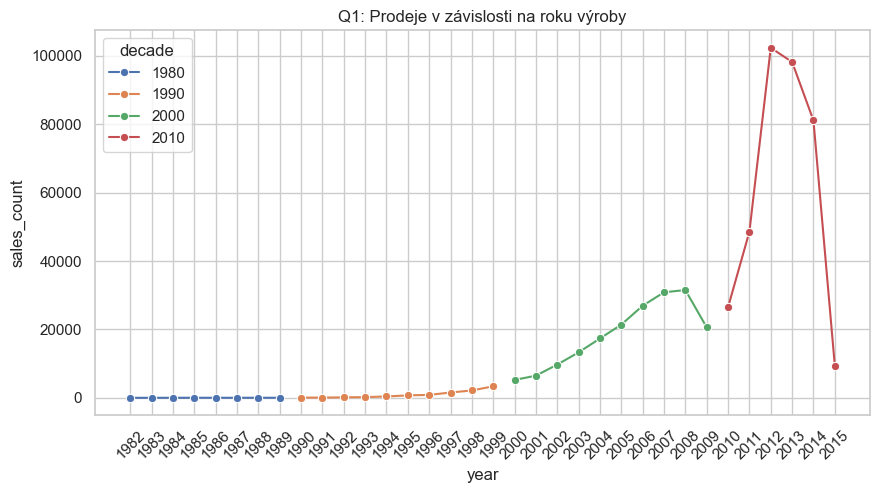

In [24]:
def plot_q1_hierarchy():
    # FILTR: Chceme řádky, kde je rok, ale model je NULL (to jsou ty mezisoučty za rok)
    df = con.execute("""
        SELECT decade, year, sales_count
        FROM results_q1_duckdb
        WHERE year NOT ILIKE 'UNKNOWN' AND model IS NULL
    """).df()

    plt.figure(figsize=(10, 5))
    # year je teď VARCHAR, seřadíme ho, aby osa X dávala smysl
    df = df.sort_values('year')

    sns.lineplot(data=df, x='year', y='sales_count', hue='decade', marker='o')
    plt.title("Q1: Prodeje v závislosti na roku výroby")
    plt.xticks(rotation=45)
    plt.savefig('../output/q1_trend.png', dpi=300, bbox_inches='tight')

    plt.show()
plot_q1_hierarchy()

## 2. 3D Analýza: Model × Karoserie × Převodovka
**Operace:** `CUBE`
**Popis:** Generuje všech 8 možných kombinací těchto tří dimenzí, ale my se v této vizualizaci zaměřujeme na 10 nejprodávanějších typů karoserií napříč všema modely. Z analýzy byly záměrně odstraněny záznamy s hodnotou **'unknown'** u převodovky a karoserie.
* **Business význam:** Marketingová analýza preferencí. Zjistíme například, zda zákazníci preferují u konkrétních modelů (např. SUV) automatickou převodovku častěji než u sedanů.
* **Klíčové metriky:** Počet prodaných kusů a průměrná prodejní cena.

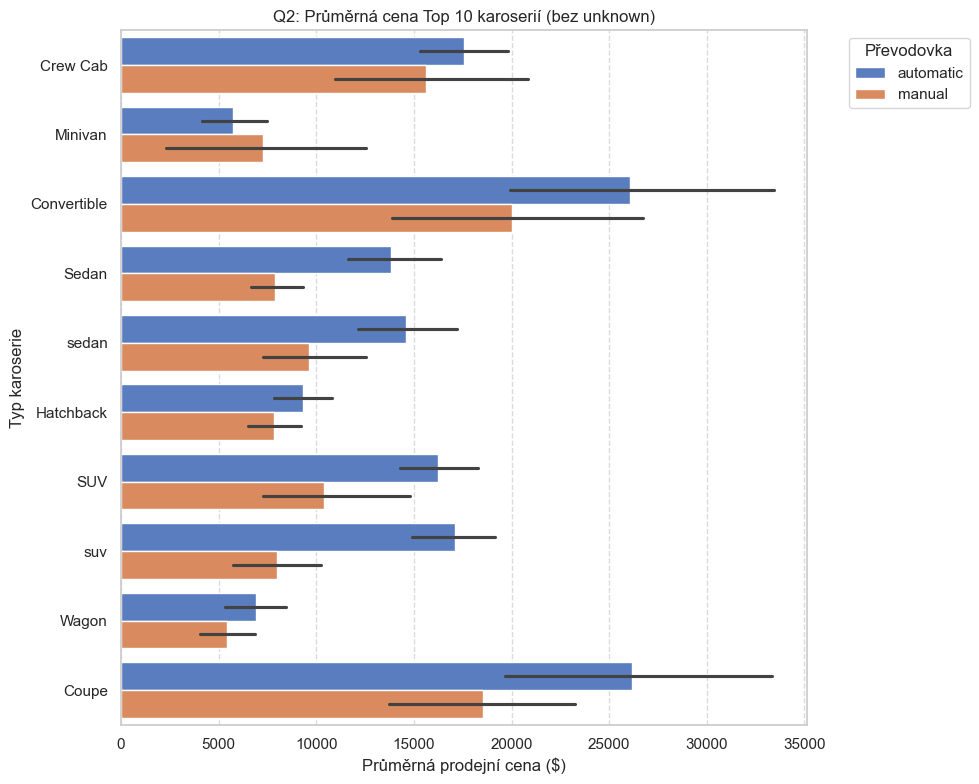

In [25]:
def plot_q2_cube():
    # Dotaz nad results_q2_duckdb
    df = con.execute("""
        WITH filtered_data AS (
            SELECT body, transmission, avg_price, sales_count
            FROM results_q2_duckdb
            WHERE transmission NOT ILIKE 'UNKNOWN'
              AND transmission NOT ILIKE 'UNKNOWN'
              AND body NOT ILIKE 'UNKNOWN'
              AND body != 'ALL BODIES'
        ),
        top_10_bodies AS (
            SELECT body
            FROM filtered_data
            GROUP BY body
            ORDER BY SUM(sales_count) DESC
            LIMIT 10
        )
        SELECT body, transmission, avg_price -- Tady se sloupec jmenuje avg_price
        FROM filtered_data
        WHERE body IN (SELECT body FROM top_10_bodies)
    """).df()

    if df.empty:
        print("⚠️ Q2: Žádná data po filtraci nezbyla.")
        return

    plt.figure(figsize=(10, 8))

    # OPRAVA: x='avg_price' (musí přesně sedět na SELECT výše)
    sns.barplot(
        data=df,
        y='body',
        x='avg_price',
        hue='transmission',
        orient='h',
        palette='muted'
    )

    plt.title("Q2: Průměrná cena Top 10 karoserií (bez unknown)")
    plt.xlabel("Průměrná prodejní cena ($)")
    plt.ylabel("Typ karoserie")
    plt.legend(title='Převodovka', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('../output/q2_cube_barplot.png', dpi=300, bbox_inches='tight')
    plt.show()
plot_q2_cube()

## 3. Selektivní řezy: Distribuce barev u Top 6 modelů
**Operace:** `GROUPING SETS` (kombinace `model` + `color`)

Tato vizualizace plně využívá komplexitu dotazu Q3. Namísto prostého žebříčku barev sledujeme barvy **v kontextu konkrétních modelů**. 

**Proč je to důležité:**
* Využíváme mezisoučty pro kombinaci `(model, color)`.
* Odhalujeme barvené preference specifické pro daný typ vozu (např. zda luxusní modely preferují černou barvu častěji než ekonomické modely).
* Data jsou filtrována tak, aby zobrazené hodnoty neobsahovaly roční souhrny ani celkové součty, čímž získáváme čistý "drill-down" pohled.

<Figure size 1200x1200 with 0 Axes>

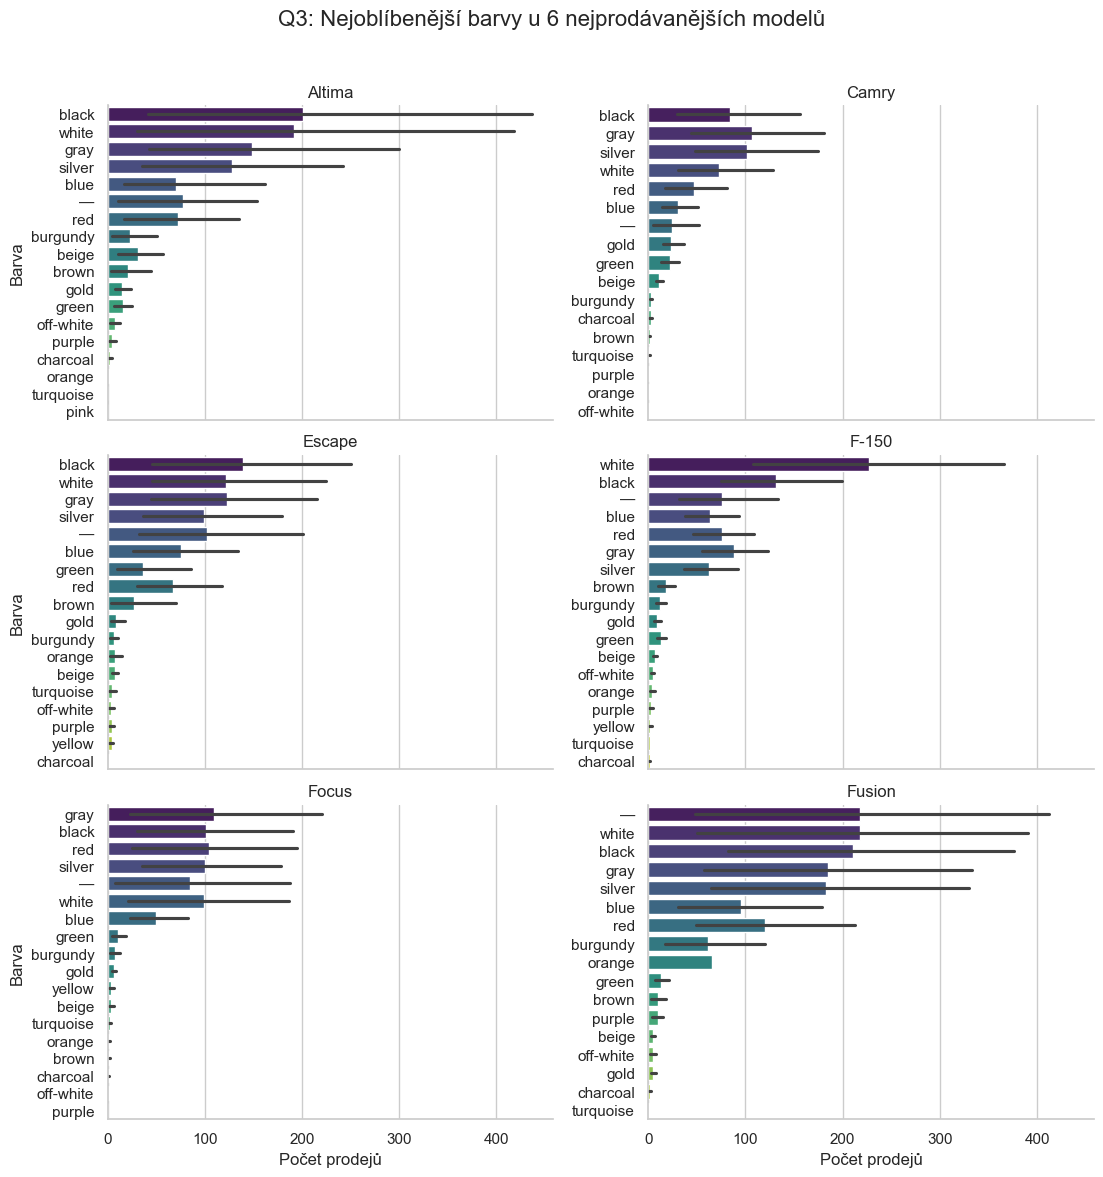

In [26]:
def plot_q3_advanced_grouping():
    # 1. Zjistíme Top 5 modelů agregací ze setu (model, color)
    # V tomto setu je year vždy NULL (v Pandas NaN)
    top_models_df = con.execute("""
        SELECT model, SUM(sales_count) as total
        FROM results_q3_duckdb
        WHERE model NOT ILIKE 'UNKNOWN'
          AND color NOT ILIKE 'UNKNOWN'
          AND year NOT ILIKE 'UNKNOWN'
        GROUP BY model
        ORDER BY total DESC
        LIMIT 6
    """).df()

    if top_models_df.empty:
        print("⚠️ Pořád prázdno. Zkusíme uvolnit filtry...")
        # Pokud by i tohle selhalo, vypíšeme si unikátní hodnoty v year
        print("Unikátní hodnoty v year:", con.execute("SELECT DISTINCT year FROM results_q3_duckdb").df())
        return

    top_models = top_models_df['model'].tolist()
    placeholders = ', '.join(["'"+str(m)+"'" for m in top_models])

    # 2. Vytáhneme barvy pro tyto modely (opět ze setu model + color)
    df = con.execute(f"""
        SELECT model, color, sales_count
        FROM results_q3_duckdb
        WHERE model IN ({placeholders})
          AND color NOT ILIKE 'UNKNOWN'
          AND year NOT ILIKE 'UNKNOWN'
        ORDER BY model, sales_count DESC
    """).df()

    # 3. Vizualizace
    plt.figure(figsize=(12, 12))
    g = sns.FacetGrid(df, col="model", col_wrap=2, sharey=False, height=4, aspect=1.4)

    # Použijeme barplot a trochu ho oživíme
    g.map_dataframe(sns.barplot, x="sales_count", y="color", palette="viridis", hue="color", legend=False)

    g.set_axis_labels("Počet prodejů", "Barva")
    g.set_titles(col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("Q3: Nejoblíbenější barvy u 6 nejprodávanějších modelů", fontsize=16)
    plt.savefig('../output/q3_facetgrid.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_q3_advanced_grouping()

## 4. Dvourozměrná analýza trhu: Objem vs. Cena
**Operace:** `ROLLUP` (agregace na úrovni značka-tělo)

Tato pokročilá heatmapa kombinuje dvě klíčové metriky v jednom pohledu:
* **Barva (škála Magma):** Reprezentuje **počet prodaných kusů**. Čím světlejší (žlutá) barva, tím vyšší tržní dominance v daném segmentu.
* **Číslo v buňce:** Udává **průměrnou prodejní cenu** v USD.

**Analytický přínos:**
Díky této vizualizaci můžeme identifikovat "High-Volume" segmenty (světlá barva, nízká cena) a "Luxury" segmenty (tmavá barva, vysoká cena). Například u značek jako Nissan či Toyota uvidíme vysokou koncentraci v sedanech, zatímco u prémiových značek uvidíme vysoká čísla (ceny) i v méně saturovaných (tmavších) buňkách.

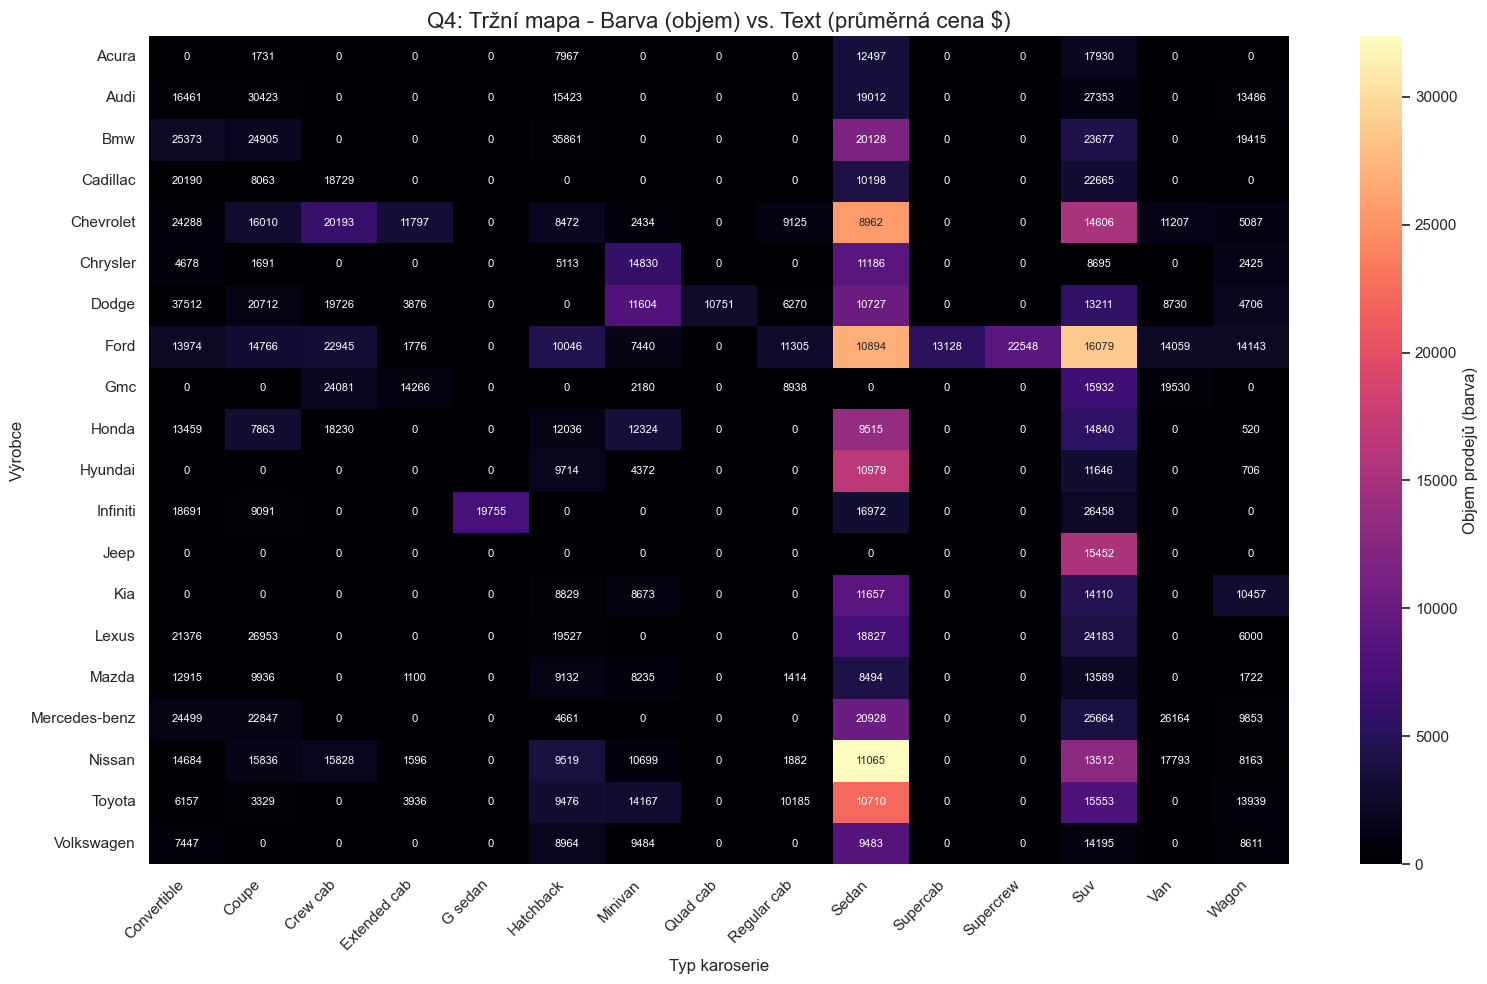

In [27]:
def plot_q4_rollup_dense():
    # 1. SQL: Musíme přidat avg_price do SELECTu
    df = con.execute("""
        SELECT make, body, sales_count, avg_price
        FROM results_q4_duckdb
        WHERE make IS NOT NULL AND body IS NOT NULL
          AND make NOT ILIKE 'UNKNOWN' AND body NOT ILIKE 'UNKNOWN'
          AND make != '~' AND body != '~'
    """).df()

    df['make'] = df['make'].str.capitalize()
    df['body'] = df['body'].str.capitalize()

    # 2. Definice TOP kategorií (aby to nebylo přeplácané, doporučuji 25x15)
    top_makes = df.groupby('make')['sales_count'].sum().nlargest(20).index
    top_bodies = df.groupby('body')['sales_count'].sum().nlargest(15).index

    df_dense = df[df['make'].isin(top_makes) & df['body'].isin(top_bodies)]

    # 3. Pivot pro BARVY (Sales Count)
    pivot_count = df_dense.pivot_table(
        index='make', columns='body', values='sales_count', aggfunc='sum'
    ).fillna(0)

    # 4. Pivot pro TEXT (Avg Price)
    pivot_price = df_dense.pivot_table(
        index='make', columns='body', values='avg_price', aggfunc='mean'
    ).fillna(0)

    # 5. Vykreslení
    plt.figure(figsize=(16, 10))

    # Použijeme annot=pivot_price pro zobrazení cen
    # fmt=".0f" zaokrouhlí ceny na celá čísla
    # annot_kws nastaví menší písmo, aby se to do okének vešlo
    sns.heatmap(
        pivot_count,
        annot=pivot_price,
        fmt=".0f",
        cmap="magma",
        cbar_kws={'label': 'Objem prodejů (barva)'},
        annot_kws={"size": 8}
    )

    plt.title("Q4: Tržní mapa - Barva (objem) vs. Text (průměrná cena $)", fontsize=16)
    plt.xlabel("Typ karoserie", fontsize=12)
    plt.ylabel("Výrobce", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../output/q4_heatmap.png', dpi=300, bbox_inches='tight')

    plt.show()

plot_q4_rollup_dense()

## 5. Segmentační matice: Model × Převodovka × Cenová třída
**Operace:** `CUBE` (všechny kombinace)

Tato pokročilá vizualizace rozkládá trh na atomární úroveň. Pro 10 nejprodávanějších modelů sledujeme distribuci cenových segmentů odděleně pro automatické a manuální převodovky.

**Struktura matice:**
* **Řádky:** Top 10 nejoblíbenějších modelů.
* **Sloupce:** Typ převodovky (Automatic vs. Manual).
* **Obsah:** Podíl segmentů **Budget**, **Mid-Range** a **Premium** v dané kombinaci.

**Analytický přínos:**
Umožňuje identifikovat, zda konkrétní technická specifikace (převodovka) přímo koreluje s cenovým segmentem u konkrétního modelu. Odhalujeme tak "upselling" potenciál – tedy zda jsou zákazníci ochotni připlácet za prémiové segmenty u specifických typů řazení.

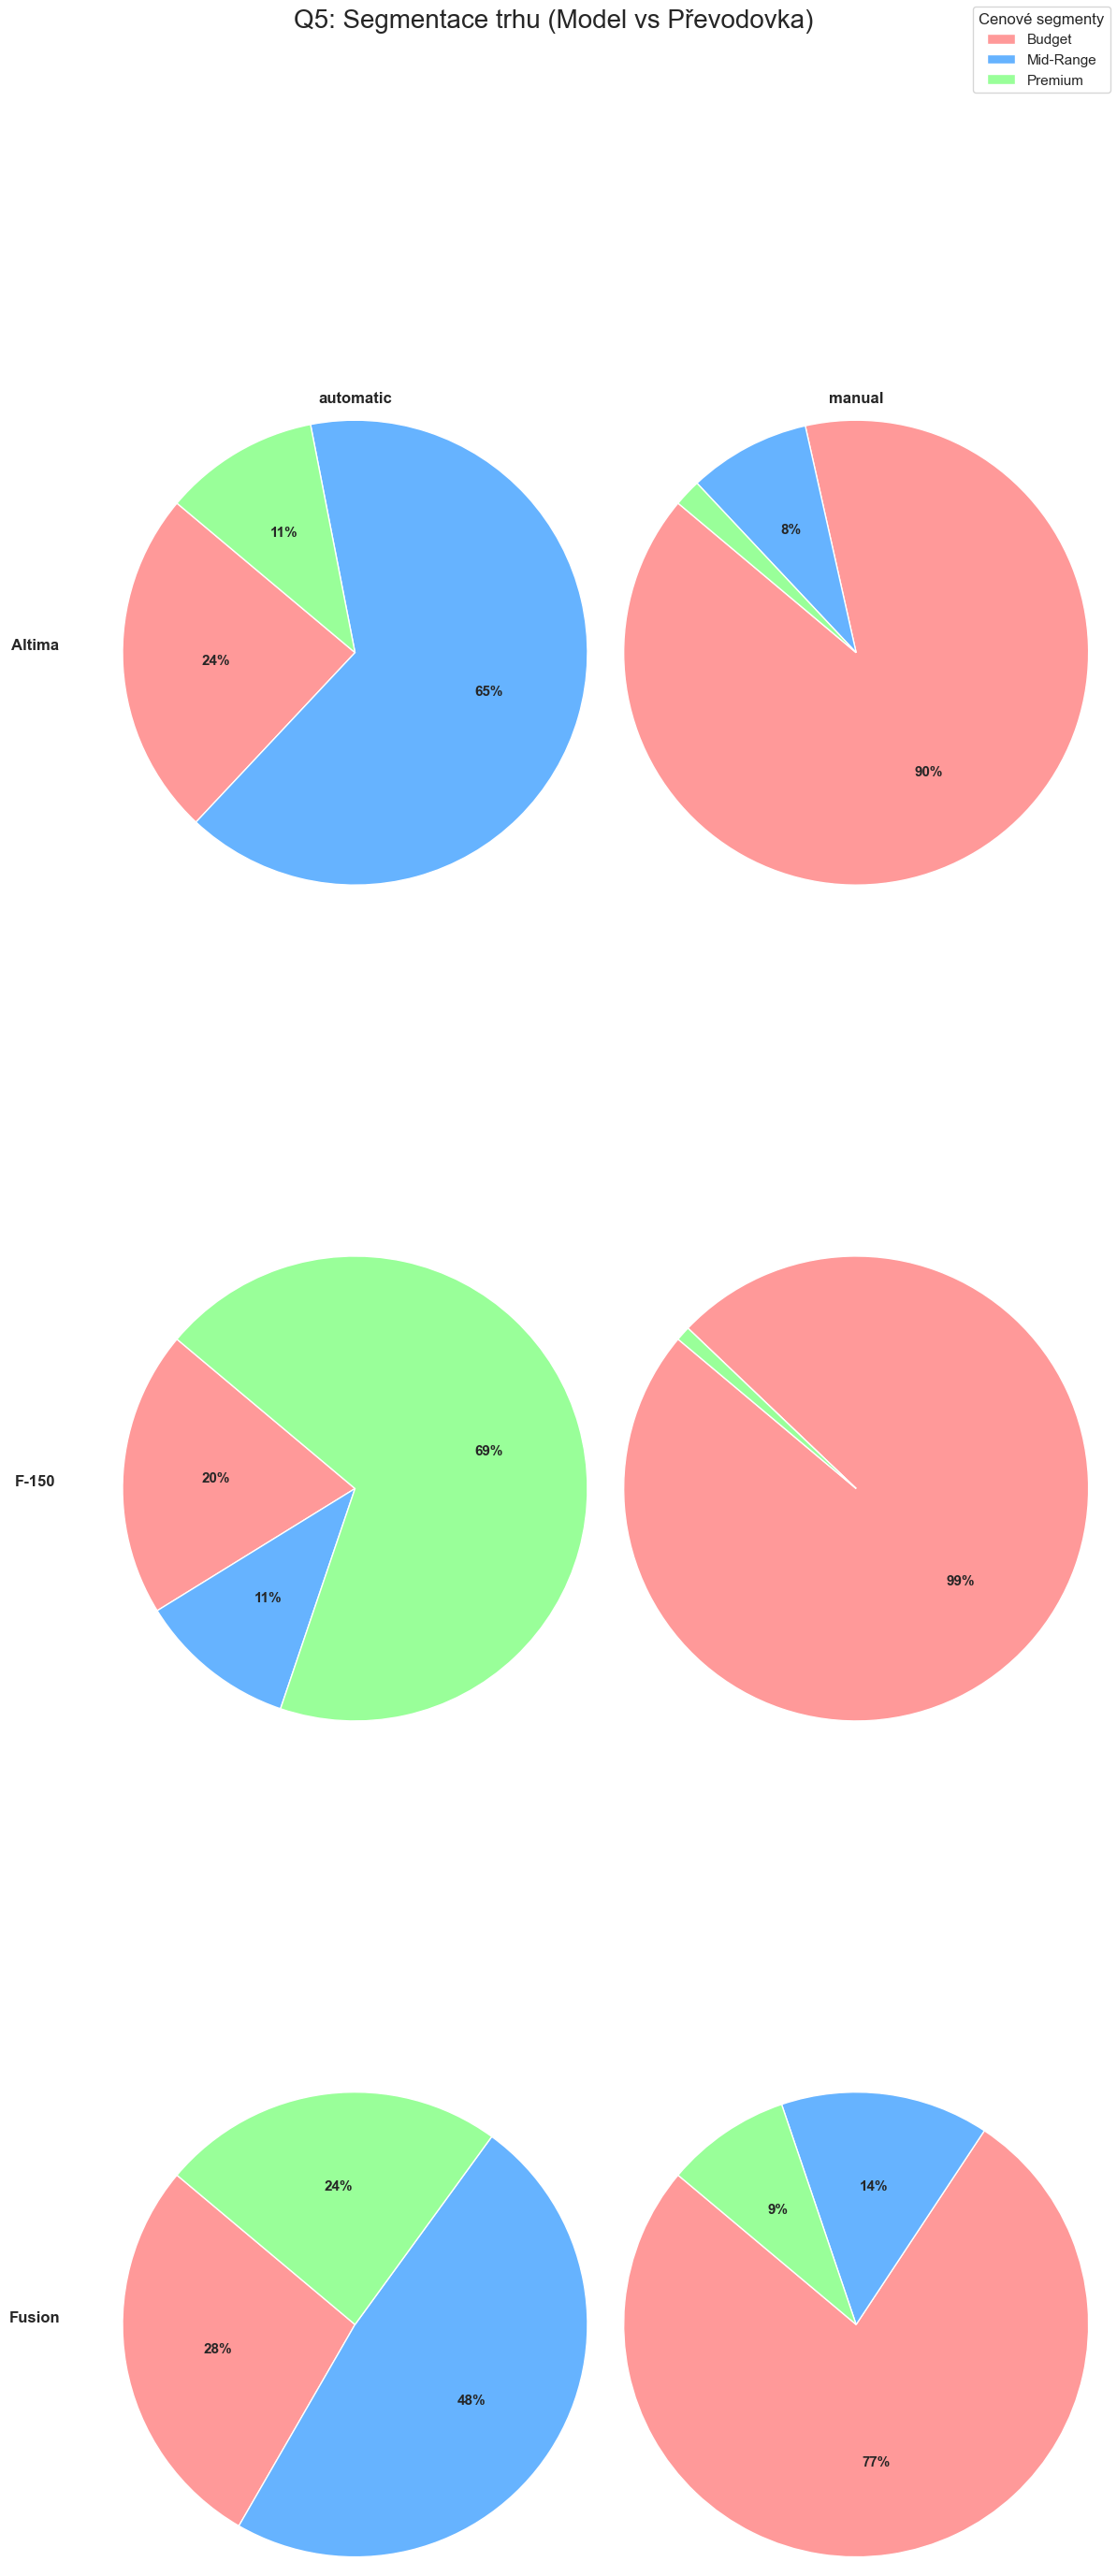

In [ ]:
def plot_q5_segments_matrix():
    # 1. Získáme Top 3 modelů (podle celkových prodejů)
    top_models = con.execute("""
        SELECT model, SUM(sales_count) as total
        FROM results_q5_duckdb
        WHERE model IS NOT NULL AND segment IS NULL AND transmission IS NULL
        GROUP BY model ORDER BY total DESC LIMIT 3
    """).df()['model'].tolist()

    # 2. Vytáhneme data pro tyto modely (všechny tři dimenze NOT NULL)
    placeholders = ', '.join(["'"+str(m)+"'" for m in top_models])
    df = con.execute(f"""
        SELECT model, transmission, segment, sales_count
        FROM results_q5_duckdb
        WHERE model IN ({placeholders})
          AND transmission NOT ILIKE 'unknown' AND transmission IS NOT NULL
          AND segment IS NOT NULL
    """).df()

    transmissions = sorted(df['transmission'].unique())
    segments_order = ['Budget', 'Mid-Range', 'Premium']
    colors = ['#ff9999', '#66b3ff', '#99ff99'] # Červená, Modrá, Zelená

    # 3. Nastavení mřížky (10 řádků, počet sloupců podle převodovek)
    fig, axes = plt.subplots(len(top_models), len(transmissions), figsize=(12, 18))
    fig.suptitle('Q5: Segmentace trhu (Model vs Převodovka)', fontsize=20, y=1.02)

    for r, model in enumerate(top_models):
        for c, trans in enumerate(transmissions):
            ax = axes[r, c]
            # Filtrace dat pro konkrétní buňku matice
            subset = df[(df['model'] == model) & (df['transmission'] == trans)]

            if not subset.empty:
                # Seřadíme segmenty, aby barvy seděly
                subset = subset.set_index('segment').reindex(segments_order).fillna(0).reset_index()

                ax.pie(subset['sales_count'],
                       autopct=lambda p: '{:.0f}%'.format(p) if p > 5 else '',
                       colors=colors,
                       startangle=140,
                       radius=1.2, # Koláč je větší než standardní jednotka
                       textprops={'fontsize': 11, 'fontweight': 'bold'})

                if r == 0: ax.set_title(f"{trans}", fontweight='bold')
                if c == 0: ax.set_ylabel(f"{model}", rotation=0, labelpad=60, fontweight='bold', fontsize=12)
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
                ax.axis('off')

    # Společná legenda pro všechny grafy
    fig.legend(segments_order, loc='upper right', title="Cenové segmenty")
    plt.tight_layout()
    plt.savefig('../output/q5_segments_matrix.png', dpi=300, bbox_inches='tight')

    plt.show()


plot_q5_segments_matrix()

## Q6: Multidimenzionální analýza (GROUPING SETS)
Tento dotaz je nejpokročilejší ukázkou OLAP operací. Pomocí `GROUPING SETS` definujeme čtyři různé pohledy na data v rámci jednoho výsledku:
1. **Produktový pohled**: Agregace podle Značky a Modelu.
2. **Strukturální trend**: Prodeje podle Roku a Typu karoserie.
3. **Rok výroby**: Celkové prodeje podle roku výroby.
4. **Globální součet**: Grand Total celého datasetu.

Následující vizualizace rozebírají tyto "ostrovy" dat samostatně.

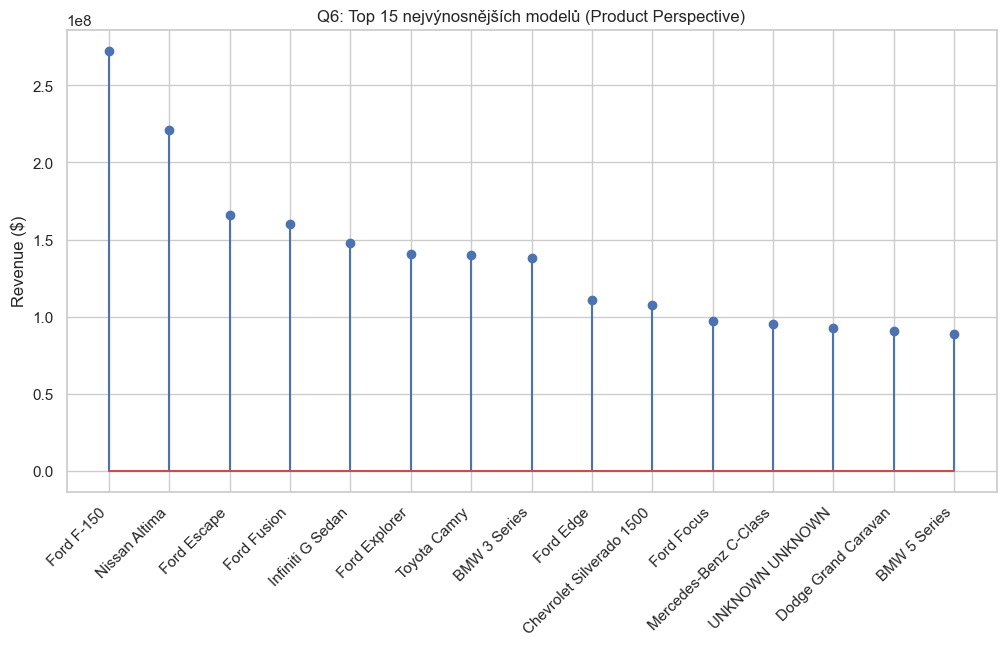

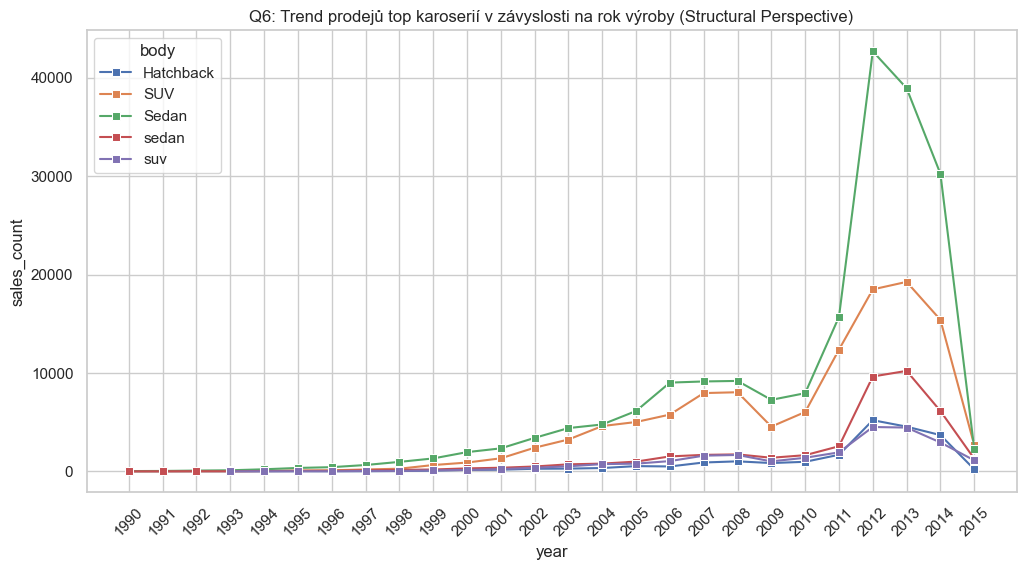

In [29]:
def plot_q6_product_analysis():
    # POHLED 1: Top 15 kombinací Značka + Model
    # Podmínka: make i model musí být NOT NULL, ale year musí být NULL (aby to byl Set 1)
    df = con.execute("""
        SELECT make, model, total_revenue
        FROM results_q6_duckdb
        WHERE make IS NOT NULL AND model IS NOT NULL AND year IS NULL
        ORDER BY total_revenue DESC
        LIMIT 15
    """).df()

    if df.empty:
        print("⚠️ Q6 (Product): Žádná data nenalezena. Zkontroluj export z Go.")
        return

    df['label'] = df['make'] + " " + df['model']

    plt.figure(figsize=(12, 6))
    plt.stem(df['label'], df['total_revenue'])
    plt.xticks(rotation=45, ha='right')
    plt.title("Q6: Top 15 nejvýnosnějších modelů (Product Perspective)")
    plt.ylabel("Revenue ($)")
    plt.savefig('../output/q6_product_analysis.png', dpi=300, bbox_inches='tight')

    plt.show()

def plot_q6_body_trends():
    # POHLED 2: Trendy typů karoserie v čase
    # Podmínka: year i body musí být NOT NULL, ale make musí být NULL (Set 2)
    df = con.execute("""
        SELECT year, body, sales_count
        FROM results_q6_duckdb
        WHERE year IS NOT NULL AND body IS NOT NULL AND make IS NULL
        ORDER BY year ASC
    """).df()

    if df.empty:
        print("⚠️ Q6 (Body): Žádná data nenalezena. Zkontroluj, zda v Go sedí názvy sloupců.")
        return

    plt.figure(figsize=(12, 6))
    # Vybereme jen top 5 karoserií, aby graf nebyl přeplácaný
    top_bodies = df.groupby('body')['sales_count'].sum().nlargest(5).index
    df_plot = df[df['body'].isin(top_bodies)]

    sns.lineplot(data=df_plot, x='year', y='sales_count', hue='body', marker='s')
    plt.title("Q6: Trend prodejů top karoserií v závyslosti na rok výroby (Structural Perspective)")
    plt.xticks(rotation=45)
    plt.savefig('../output/q6_body_trends.png', dpi=300, bbox_inches='tight')

    plt.show()

# Spuštění

plot_q6_product_analysis()
plot_q6_body_trends()

# Sekce 2: Data Mining a Pokročilá Statistika
V této části aplikujeme algoritmy strojového učení bez učitele (Clustering) a statistické modelování (Regrese) pro hlubší pochopení skrytých vzorců v datech.


### A. Clustering (K-Means)
Cílem je automaticky segmentovat trh automobilů na základě ceny a nájezdu (odometr). Tato metoda nahrazuje ruční škatulkování a nachází přirozené skupiny (např. "sběratelské kousky", "ojetiny na dojetí", "standardní ojetiny").

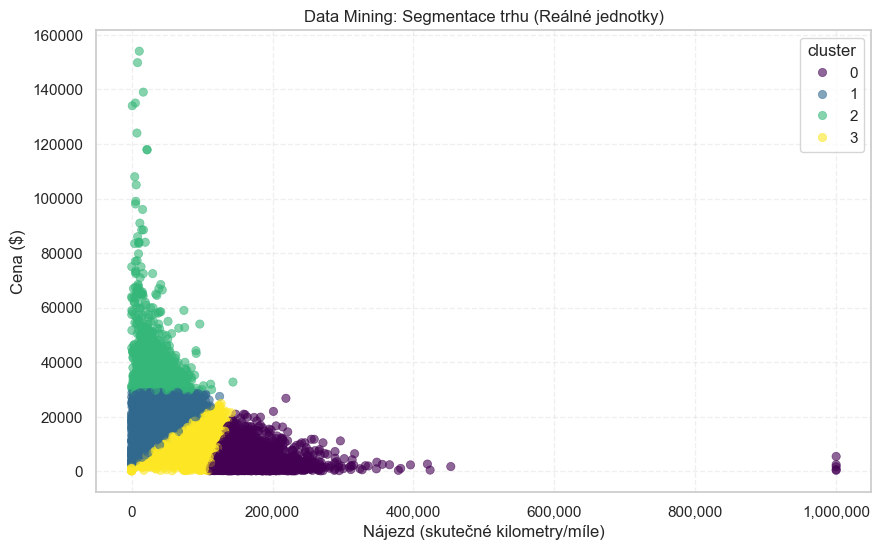

In [30]:
# 1. Načtení dat (v dolarech a kilometrech)
df_km = con.execute("""
    SELECT selling_price, odometer
    FROM raw_sales
    WHERE odometer IS NOT NULL AND selling_price IS NOT NULL
    LIMIT 20000
""").df()

# 2. SCALING (jen pro "mozek" algoritmu)
scaler = StandardScaler()
# Scalujeme do dočasné proměnné, neupravujeme si původní df_km
df_scaled = scaler.fit_transform(df_km[['selling_price', 'odometer']])

# 3. K-MEANS (běží na scaled datech)
kmeans = KMeans(n_clusters=4, n_init='auto', random_state=42)
# Shluky (0, 1, 2, 3) uložíme jako nový sloupec do PŮVODNÍHO dataframe
df_km['cluster'] = kmeans.fit_predict(df_scaled)

# --- VIZUALIZACE S REÁLNOU OSOU ---
plt.figure(figsize=(10, 6))

# Tady je ta finta: Plotujeme reálný odometer a reálnou cenu z df_km,
# ale barvu (hue) bereme z vypočítaných clusterů.
sns.scatterplot(
    data=df_km,
    x='odometer',
    y='selling_price',
    hue='cluster',
    palette='viridis',
    alpha=0.6,
    edgecolor=None
)

# Formátování osy X, aby tam nebyla vědecká notace (např. 1e5)
from matplotlib.ticker import FuncFormatter
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Data Mining: Segmentace trhu (Reálné jednotky)")
plt.xlabel("Nájezd (skutečné kilometry/míle)")
plt.ylabel("Cena ($)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig('../output/kmeans_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

### B. Lineární regrese (Predikce trendu)
Analýza vývoje cenové hladiny v závislosti na stáří vozidla. Model se snaží predikovat, jaká bude průměrná cena automobilu v budoucích letech na základě historických dat.

Provádím Lineární regresi...


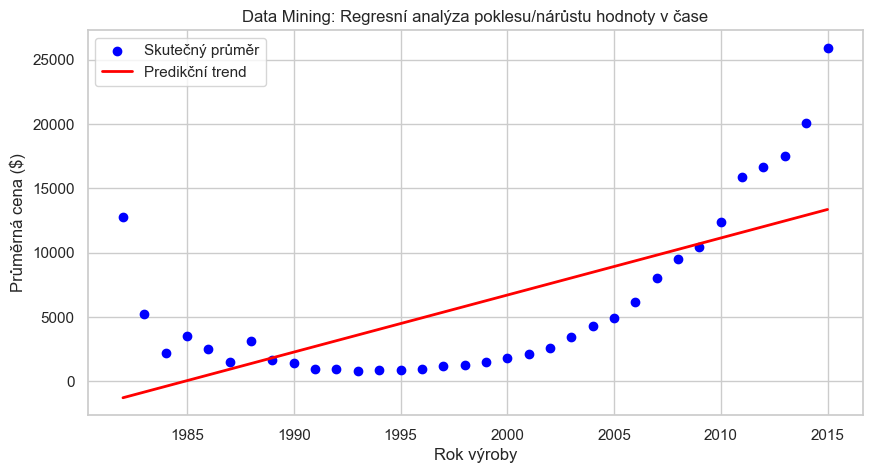

In [31]:
# --- 2. REGRESE / PREDIKCE (Linear Regression) ---
# Predikce ceny na základě roku výroby
print("Provádím Lineární regresi...")
df_reg = con.execute("""
    SELECT year_int, AVG(selling_price) as avg_price
    FROM raw_sales
    GROUP BY year_int
    ORDER BY year_int
""").df()

X = df_reg[['year_int']]
y = df_reg['avg_price']
reg = LinearRegression().fit(X, y)
df_reg['prediction'] = reg.predict(X)

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', label='Skutečný průměr')
plt.plot(X, df_reg['prediction'], color='red', linewidth=2, label='Predikční trend')
plt.xlabel("Rok výroby")
plt.ylabel("Průměrná cena ($)")
plt.legend()
plt.title("Data Mining: Regresní analýza poklesu/nárůstu hodnoty v čase")
plt.savefig('../output/regression_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### C. Detekce Anomálií (Z-Score)
Identifikace podezřelých prodejů, kde se cena výrazně liší od tržního odhadu (MMR). Model vyhledává extrémní odchylky, které nespadají do běžného statistického rozptylu.

Metoda: Pravidlo $3\sigma$ (anomálie je vše, co leží mimo interval tří směrodatných odchylek od průměru).

Význam: Odhalení chyb v datech (překlepy v ceně), podvodných transakcí nebo extrémně podhodnocených/nadhodnocených nabídek.


### C. Vizualizace anomálií: Skutečná cena vs. Tržní odhad
Tento graf zobrazuje vztah mezi prodejní cenou a odhadovanou tržní hodnotou (MMR). 

* **Diagonála:** Body blízko diagonály představují běžné prodeje odpovídající trhu.
* **Barevné body:** Označují statistické anomálie ($|Z| > 3$). 
* **Horní oblast:** Vozy prodané výrazně nad tržní cenou (potenciální spekulace nebo chyby v datech).
* **Dolní oblast:** Vozy prodané hluboko pod cenou (potenciální podvody nebo skryté vady).

Nalezeno 8177 cenových anomálií.


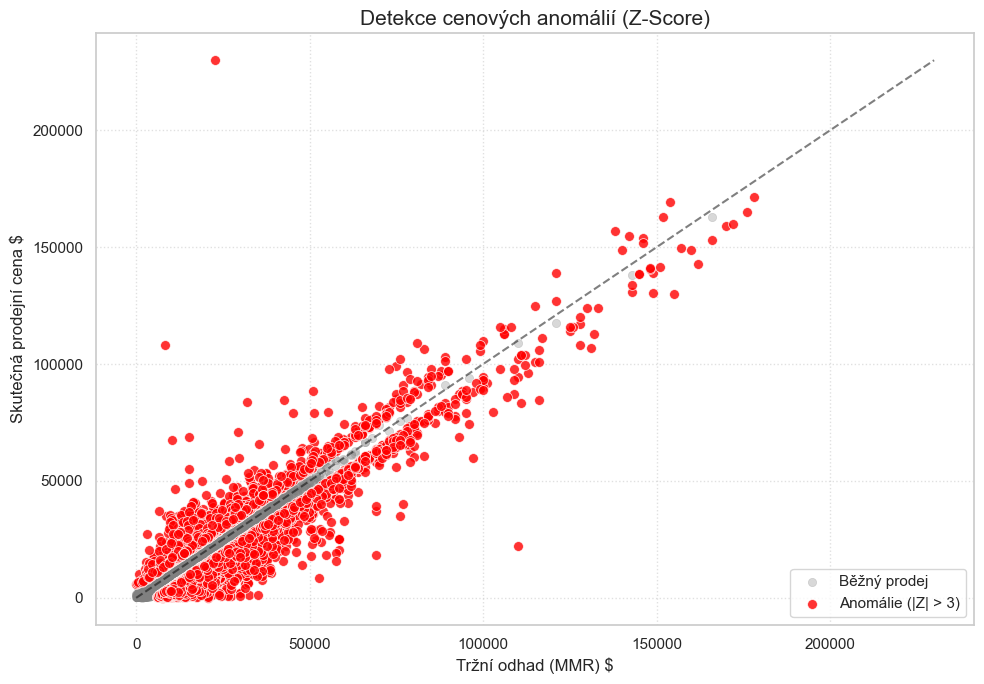

In [32]:
def plot_anomaly_detection():
    # 1. Načteme data včetně cen pro osy grafu
    df_plot = con.execute("""
        SELECT selling_price, mmr, (selling_price - mmr) as diff
        FROM raw_sales
        WHERE mmr > 0
    """).df()

    # 2. Výpočet Z-Score
    mean_diff = df_plot['diff'].mean()
    std_diff = df_plot['diff'].std()
    df_plot['is_anomaly'] = df_plot['diff'].apply(lambda x: abs(x - mean_diff) > 3 * std_diff)

    print(f"Nalezeno {df_plot['is_anomaly'].sum()} cenových anomálií.")


    # 3. Vizualizace
    plt.figure(figsize=(10, 7))

    # Vykreslíme nejdřív normální data (šedě a poloprůhledně)
    sns.scatterplot(
        data=df_plot[~df_plot['is_anomaly']].sample(min(10000, len(df_plot))),
        x='mmr', y='selling_price',
        color='gray', alpha=0.3, label='Běžný prodej', edgecolor=None
    )

    # Poté vykreslíme anomálie (červeně)
    sns.scatterplot(
        data=df_plot[df_plot['is_anomaly']],
        x='mmr', y='selling_price',
        color='red', alpha=0.8, label='Anomálie (|Z| > 3)', s=50
    )

    # Přidáme diagonálu (ideální shoda ceny a MMR)
    max_val = max(df_plot['mmr'].max(), df_plot['selling_price'].max())
    plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', alpha=0.5)

    plt.title("Detekce cenových anomálií (Z-Score)", fontsize=15)
    plt.xlabel("Tržní odhad (MMR) $")
    plt.ylabel("Skutečná prodejní cena $")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig('../output/anomaly_detection.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_anomaly_detection()
